# Closed shops analysis

Dataset description says some stores were closed for refurbishment. Lets dive deeper and understand closed shops behavior.

In [2]:
from google.colab import drive
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
ROOT_PATH = Path("/content/drive/MyDrive/data/store-sales-forecasting/")
df = pd.read_csv(ROOT_PATH / "train.csv")
df = df.set_index('Date')
df.index = pd.to_datetime(df.index)

/tmp/ipykernel_952/2917071980.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ROOT_PATH / "train.csv")


In [5]:
rows, columns = df.shape

print(f"Rows: {rows}\nColumns: {columns}")

Rows: 1017209
Columns: 8


Total sales in closed shops - 0
Closed stores ratio: 16.99%


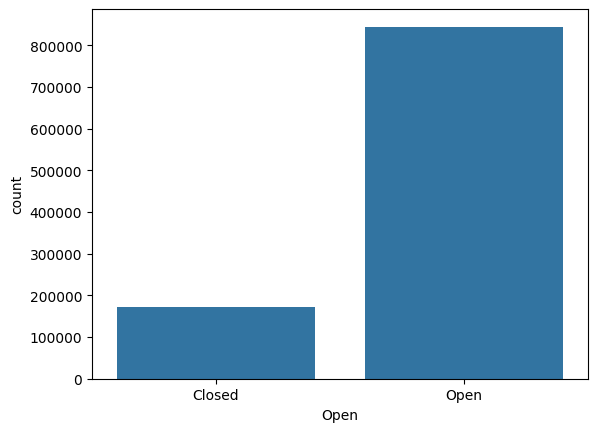

In [49]:
sns.countplot(df, x="Open")

print(f"Total sales in closed shops - {df[df["Open"] == 0]["Sales"].sum()}")
print(f"Closed stores ratio: {(df["Open"]==0).sum() / rows *100:.2f}%")

plt.xticks(ticks=[0, 1], labels=["Closed", "Open"])
plt.show()

In [7]:
def check_closed_shops_sold_later(df):
    """
    Check if stores sold something after being closed.
    Tracks all closing events (contiguous periods where Open==0).
    """
    closed_shop_ids = df.loc[df["Open"] == 0, "Store"].unique()
    results = []

    for store_id in closed_shop_ids:
        # Get store sales history (sorted by dates)
        store_df = df[df["Store"] == store_id].sort_index()
        is_closed = store_df["Open"] == 0

        # Detect contiguous closed periods
        period_id = (is_closed != is_closed.shift()).cumsum()
        
        for _, period_group in store_df.groupby(period_id): # Matching by DateTimeIndex
            if period_group["Open"].iloc[0] == 0:
                last_closed = period_group.index.max()

                after_df = store_df.loc[store_df.index > last_closed]
                sold_after = (after_df["Sales"] > 0).any()
                first_sale = after_df.loc[after_df["Sales"] > 0].index.min() if sold_after else pd.NaT

                results.append({
                    "Store": store_id,
                    "last_closed_date": last_closed,
                    "sold_after": sold_after,
                    "first_sale_after": first_sale,
                })

    return pd.DataFrame(results)

report_path = ROOT_PATH / "closed_report.csv"
if report_path.exists():
    closed_report = pd.read_csv(report_path)
    closed_report["last_closed_date"] = pd.to_datetime(closed_report["last_closed_date"])
    closed_report["first_sale_after"] = pd.to_datetime(closed_report["first_sale_after"])
else:
    closed_report = check_closed_shops_sold_later(df)
    closed_report.to_csv(report_path)

In [8]:
print(f"Shops that were closed at some point: {len(closed_report)}")
print(f"Shops that sold after closing: {closed_report['sold_after'].sum()}")
print(f"Shops that never sold after last closure: {(~closed_report['sold_after']).sum()}")

closed_df = closed_report.groupby(["last_closed_date", "first_sale_after"]).size() \
    .reset_index(name="num_closed_stores")
closed_df["closed_days"] = (closed_df["first_sale_after"] - closed_df["last_closed_date"]).dt.days
closed_df["DayOfWeek"] = closed_df["last_closed_date"].dt.day_of_week
print(f"\nUnique closing dates and number of closed stores:")
        
closed_df.sort_values(["closed_days", "num_closed_stores"], ascending=False)

Shops that were closed at some point: 161633
Shops that sold after closing: 161631
Shops that never sold after last closure: 2

Unique closing dates and number of closed stores:


,last_closed_date,first_sale_after,num_closed_stores,closed_days,DayOfWeek
81,2013-09-01,2013-09-25,1,24,6
150,2014-04-28,2014-05-05,1,7,0
199,2014-09-30,2014-10-06,1,6,1
43,2013-05-06,2013-05-11,1,5,0
167,2014-06-30,2014-07-05,1,5,0
...,...,...,...,...,...
256,2015-04-28,2015-04-29,1,1,1
259,2015-05-06,2015-05-07,1,1,2
264,2015-05-24,2015-05-25,1,1,6
271,2015-06-25,2015-06-26,1,1,3


In [9]:
closed_df.columns

Index(['last_closed_date', 'first_sale_after', 'num_closed_stores',
       'closed_days', 'DayOfWeek'],
      dtype='object')

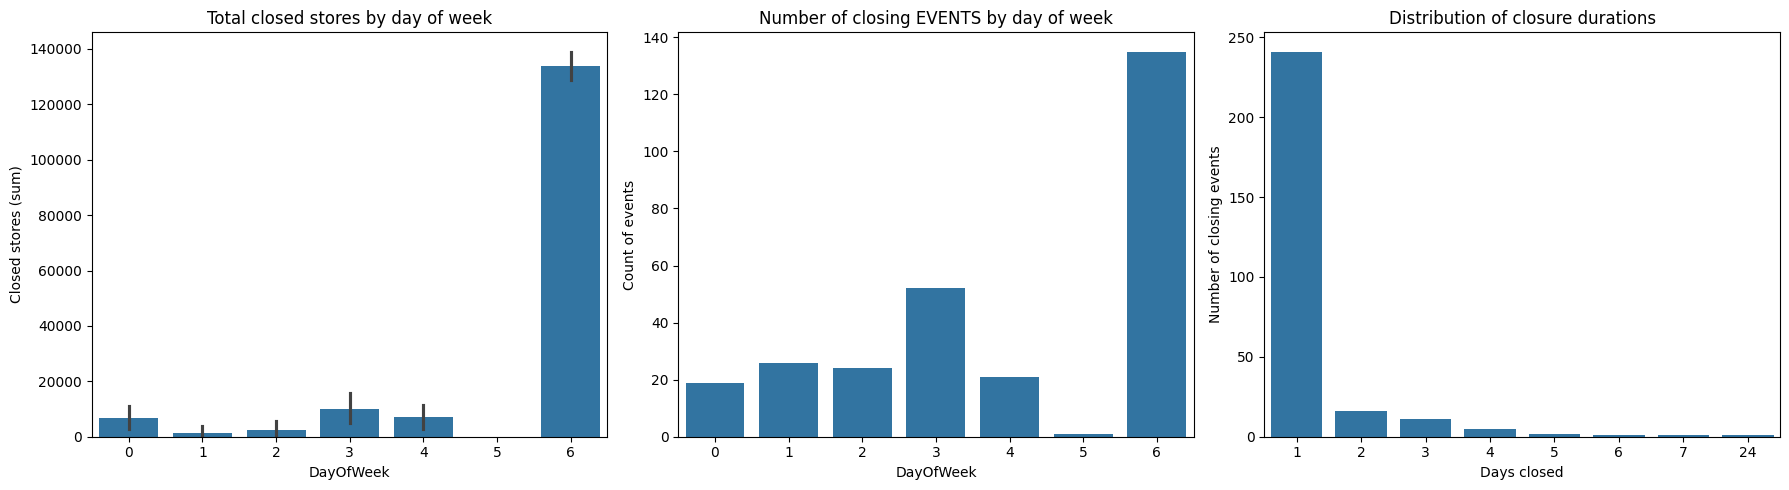

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(closed_df, y="num_closed_stores", x="DayOfWeek", ax=ax[0], estimator=sum)
ax[0].set_title("Total closed stores by day of week")
ax[0].set_ylabel("Closed stores (sum)")

sns.countplot(closed_df, x="DayOfWeek", ax=ax[1])
ax[1].set_title("Number of closing EVENTS by day of week")
ax[1].set_ylabel("Count of events")

sns.countplot(closed_df, x="closed_days", order=sorted(closed_df["closed_days"].unique()), ax=ax[2])
ax[2].set_title("Distribution of closure durations")
ax[2].set_ylabel("Number of closing events")
ax[2].set_xlabel("Days closed")
plt.tight_layout()
plt.show()

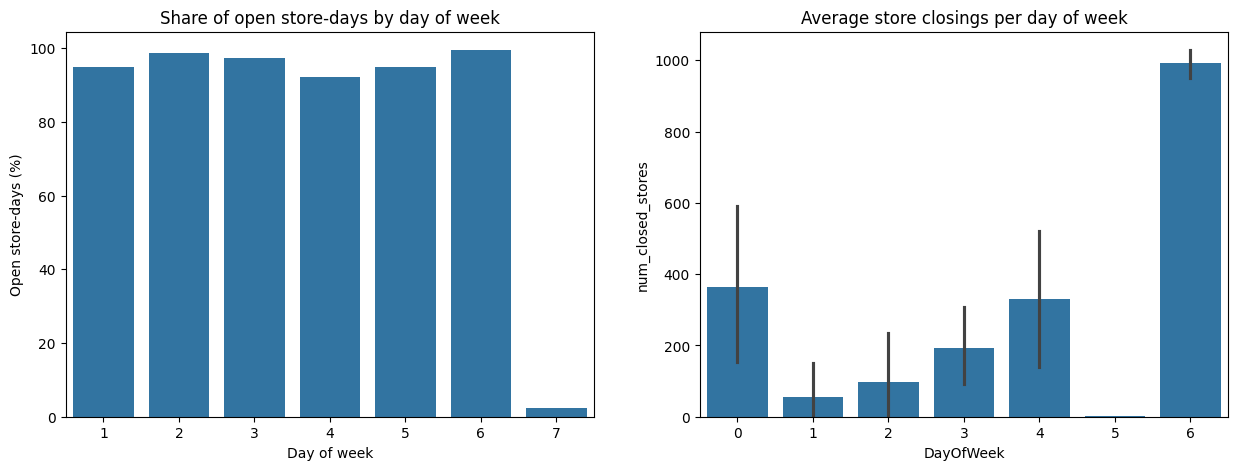

In [59]:
fig, ax = plt.subplots(1,2, figsize=(15,5))


open_share_by_dow = df.groupby("DayOfWeek")["Open"].mean() * 100
sns.barplot(x=open_share_by_dow.index, y=open_share_by_dow.values, ax=ax[0])
ax[0].set_title("Share of open store-days by day of week")
ax[0].set_xlabel("Day of week")
ax[0].set_ylabel("Open store-days (%)")

sns.barplot(closed_df, y="num_closed_stores", x="DayOfWeek", estimator="mean", ax=ax[1])
ax[1].set_title("Average store closings per day of week")

plt.show()

In [46]:
sundays = closed_df[closed_df["DayOfWeek"] == 6]
sd_closing = sundays["last_closed_date"].nunique()

print(f"Total UNIQUE sundays, when all stores were closed: {sd_closing}")
print(f"Total UNIQUE sundays dates in dataset: {df[df["DayOfWeek"] == 6].index.unique().shape[0]}")

Total UNIQUE sundays, when all stores were closed: 132
Total UNIQUE sundays dates in dataset: 134


We see that most part of closings are at sundays. But actually not all stores are closed at sundays. Also we see additional 2 sundays were all stores were open

Mostly the key takeaway will be the fact that close label is pretty tricky: it will be difficult to understand stores that are closed for construction from weekdays / holidays closings
    - And actually do not need to: the amount of such stores is small